In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import matplotlib.patches as patches
import scipy
import pandas as pd
import os
from datetime import datetime


# import pickle
# import itertools
from concurrent.futures import ProcessPoolExecutor

from matplotlib.lines import Line2D
import matplotlib as mpl
import pandas as pd
import seaborn as sns
sns.set_context("paper") 


In [2]:

from pyprojroot import here

import importlib.util

_spec = importlib.util.spec_from_file_location("opinion_functions", here() / "src" / "opinion_functions.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
fun = _mod

_spec = importlib.util.spec_from_file_location("generate_homophilic_graph_symmetric", here() / "src" / "generate_homophilic_graph_symmetric.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
generate_homophilic_graph_symmetric = _mod

_spec = importlib.util.spec_from_file_location("generate_homophilic_graph_asymmetric", here() / "src" / "generate_homophilic_graph_asymmetric.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
generate_homophilic_graph_asymmetric = _mod

_spec = importlib.util.spec_from_file_location("generate_homophilic_SB_graph", here() / "src" / "generate_homophilic_SB_graph.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
generate_homophilic_SB_graph = _mod



In [3]:
# Use Helvetica everywhere
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
mpl.rcParams['font.weight'] = 'normal'

# Optional: ensure mathtext looks more Helvetica-like
mpl.rcParams['mathtext.fontset'] = 'dejavusans'
mpl.rcParams['mathtext.default'] = 'regular'

In [4]:

colors=["#0091ff",'#f2d138', '#7fc960', "#a589ee"] #majority/minority
maj_color = colors[0]
min_color = colors[1]
min_maj_color = colors[2]
maj_min_color = colors[3]
greycolor='#626262'
lightgreycolor='#c4c4c4'
myblack='#222222'


SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 12

# --- FONT SIZES ----------------------------------------------------------
TITLE_SIZE = 9
LABEL_SIZE = 8
TICK_SIZE = 8
ANNOT_SIZE = 7
LEGEND_SIZE = 7

linewidth=0.5
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def customize_axes(ax,myblack):
    ax.spines['top'].set_color(myblack)
    ax.spines['bottom'].set_color(myblack)
    ax.spines['left'].set_color(myblack)
    ax.spines['right'].set_color(myblack)
    ax.xaxis.label.set_color(myblack)
    ax.yaxis.label.set_color(myblack)
    ax.title.set_color(myblack)
    ax.tick_params(axis='x', colors=myblack)
    ax.tick_params(axis='y', colors=myblack)

In [5]:
def edge_colors_from_groups(G, group_attr,type=None):
    colors = []
    for u, v in G.edges():
        gu, gv = group_attr[u], group_attr[v]
        if gu == "majority" and gv == "majority":
            colors.append(maj_color)
        elif gu == "minority" and gv == "minority":
            colors.append(min_color)
        elif gu == "majority" and gv == "minority":
            if type=="BA":
                colors.append(maj_min_color)
            elif type=="SBM":
                colors.append(min_maj_color)
        elif gu == "minority" and gv == "majority":
            colors.append(min_maj_color)
    return colors


In [6]:
def two_block_layout(G, minority_nodes, 
                     x_gap=0.5, y_gap=0.5,
                     maj_scale=2, min_scale=1,
                     x_spread=3,     # ← NEW: horizontal spread multiplier
                     seed=None):
    """
    Majority: upper-left, larger & spread out.
    Minority: lower-right, smaller & tighter.
    x_spread increases horizontal spread for BOTH groups.
    """
    rng = np.random.default_rng(seed)

    minority_nodes = set(minority_nodes)
    majority_nodes = [n for n in G.nodes if n not in minority_nodes]
    minority_nodes = [n for n in G.nodes if n in minority_nodes]

    pos = {}

    # --- Majority block (upper-left) ---
    n_maj = len(majority_nodes)
    if n_maj > 0:
        grid_y = np.linspace(0, 1, n_maj)
        for (y, n) in zip(grid_y, majority_nodes):
            pos[n] = np.array([
                -0.2 + x_spread * maj_scale * (0.1 * rng.normal()),   # MORE horizontal spread
                y_gap + maj_scale * (y + 0.15 * rng.normal())
            ])

    # --- Minority block (lower-right) ---
    n_min = len(minority_nodes)
    if n_min > 0:
        grid_y = np.linspace(0, 1, n_min)
        for (y, n) in zip(grid_y, minority_nodes):
            pos[n] = np.array([
                x_gap + x_spread * min_scale * (0.1 * rng.normal()),  # MORE horizontal spread
                -0.2 + min_scale * (y + 0.05 * rng.normal())
            ])

    return pos


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_block(ax, rects, maj_color, maj_min_color, min_maj_color, min_color, fontsize=SMALL_SIZE,edgecolor=myblack):
    # Draw rectangles
    for x, y, w, h, label, color in rects:
        ax.add_patch(patches.Rectangle((x, y), w, h,
                                       facecolor=color, edgecolor=edgecolor))
        ax.text(x + w/2, y + h/2, label,
                ha='center', va='center', fontsize=fontsize)

    # --- Add Column Labels ---
    ax.text(majority_w/2, 1 + minority_h + 0.15, "majority",
            ha='center', va='center', fontsize=fontsize)
    ax.text(majority_w + minority_w/2, 1 + minority_h + 0.15, "minority",
            ha='center', va='center', fontsize=fontsize)

    # --- Add Row Labels ---
    ax.text(-0.15, 1 + minority_h/3, "majority",
            ha='center', va='center', fontsize=fontsize, rotation=90)
    ax.text(-0.15, minority_h/2, "minority",
            ha='center', va='center', fontsize=fontsize, rotation=90)

    # formatting
    ax.set_xlim(-0.4, majority_w + minority_w)
    ax.set_ylim(0, 1 + minority_h + 0.4)
    ax.set_aspect('equal')
    ax.axis('off')


# # ============================================================
# # 👇 Set your majority/minority size here
# # ============================================================

majority_w = 1.0
minority_w = 0.7
majority_h = 1.0
minority_h = 0.7

# # ============================================================
# # Create a 1×2 figure
# # ============================================================

# fig, axes = plt.subplots(1, 2, figsize=(6, 4))

# # ============================================================
# # FIRST PLOT (H-in/out)
# # ============================================================

# rects1 = [
#     (0,           minority_h, majority_w, majority_h, r'$H_{\text{in}}$',   maj_color),
#     (majority_w,  minority_h, minority_w, majority_h, r'$H_{\text{out}}$', min_maj_color),

#     (0,           0,          majority_w, minority_h, r'$H_{\text{out}}$', min_maj_color),
#     (majority_w,  0,          minority_w, minority_h, r'$H_{\text{in}}$',   min_color),
# ]

# draw_block(axes[0], rects1, maj_color, None, min_maj_color, min_color)
# axes[0].set_title("Stochastic Block Model")


# # ============================================================
# # SECOND PLOT (h_aa / h_bb)
# # ============================================================

# rects2 = [
#     (0,           minority_h, majority_w, majority_h, r'$h_{\text{bb}}$',     maj_color),
#     (majority_w,  minority_h, minority_w, majority_h, r'$1-h_{\text{bb}}$',  maj_min_color),

#     (0,           0,          majority_w, minority_h, r'$1-h_{\text{aa}}$',  min_maj_color),
#     (majority_w,  0,          minority_w, minority_h, r'$h_{\text{aa}}$',     min_color),
# ]

# draw_block(axes[1], rects2, maj_color, maj_min_color, min_maj_color, min_color)
# axes[1].set_title("Preferential Attachment Model")

# plt.tight_layout()
# plt.show()



================= SEED = 32 =================

=== SBM graph ===


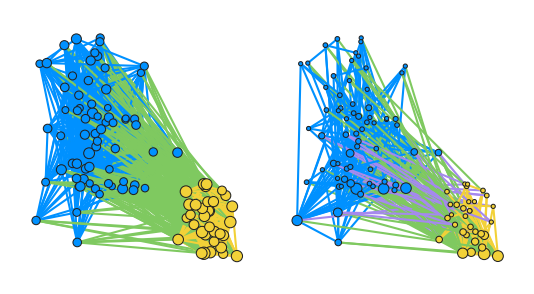

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# --- GLOBAL PARAMS ----------------------------------------------------------

dpival = 150

num_agents_top = 100       # for cartoon networks

m = 4
minority_fraction = 0.333
majority_fraction = 1 - minority_fraction

# BA homophily parameters (asymmetric)
h_ab_ba = 1 - 0.8   # minority -> majority
h_ba_ba = 1 - 0.6   # majority -> minority

# SBM homophily parameters
h_ina_sbm = 0.6
h_inb_sbm = 0.2 # majority–majority
h_out_sbm = 0.1  # between-group

# plotting options
node_size_multiplier = 1#14
kval = 2   # for BA spring layout
edge_width = 1


# --- HELPER: assign group attribute for mixing matrix -----------------------

def add_group_attribute(G, minority_nodes, attr_name="group"):
    group_attr = {n: ("minority" if n in minority_nodes else "majority")
                  for n in G.nodes()}
    nx.set_node_attributes(G, group_attr, attr_name)
    return group_attr


# ========================== MAIN LOOP ======================================

for seedval in [32]:
    print(f"\n================= SEED = {seedval} =================\n")

    # ===================== GENERATE SBM GRAPHS ==============================

    # SMALL SBM GRAPH (cartoon)
    G_sbm_small, minority_nodes_sbm_small = \
        generate_homophilic_SB_graph.homophilic_stochastic_block_graph_assym(
            N=num_agents_top,
            minority_fraction=minority_fraction,
            h_ina=h_ina_sbm,
            h_inb=h_inb_sbm,
            h_out=h_out_sbm,
            seed=seedval
        )

    group_attr_sbm_small = add_group_attribute(
        G_sbm_small, minority_nodes_sbm_small, attr_name="group"
    )
    # pos_sbm_small = nx.spring_layout(G_sbm_small, k=0.8, seed=seedval)
    pos_sbm_small = two_block_layout(G_sbm_small, minority_nodes_sbm_small, x_gap=2.0, seed=seedval)



    print("=== SBM graph ===")

    # ===================== GENERATE BA GRAPHS ===============================

    # SMALL BA GRAPH (cartoon)
    G_ba_small, minority_nodes_ba_small = \
        generate_homophilic_graph_asymmetric.homophilic_barabasi_albert_graph_assym(
            N=num_agents_top,
            m=m,
            minority_fraction=minority_fraction,
            h_ab=h_ab_ba,
            h_ba=h_ba_ba,
            seed=seedval
        )

    group_attr_ba_small = add_group_attribute(
        G_ba_small, minority_nodes_ba_small, attr_name="group"
    )
    # pos_ba_small = nx.spring_layout(G_ba_small, k=kval, seed=seedval)
    pos_ba_small = two_block_layout(G_ba_small, minority_nodes_ba_small, x_gap=2.0, seed=seedval)


    # ===================== FIGURE: COLS = MODELS ===========================

    fig, axs = plt.subplots(1, 2, dpi=dpival, figsize=(3.6, 2), sharey=False)

    # ----- Col 0: SBM cartoon network --------------------------------------
    ax = axs[0]

    colors_nodes_sbm = {
        n: min_color if group_attr_sbm_small[n] == "minority" else maj_color
        for n in G_sbm_small.nodes()
    }
    degrees_sbm_small = dict(G_sbm_small.degree)

    edge_colors_sbm = edge_colors_from_groups(G_sbm_small, group_attr_sbm_small,type="SBM")

    nx.draw_networkx_edges(
        G_sbm_small, pos=pos_sbm_small,
        edge_color=edge_colors_sbm, ax=ax, width=edge_width
    )
    nx.draw_networkx_nodes(
        G_sbm_small,
        pos=pos_sbm_small,
        nodelist=list(G_sbm_small.nodes()),
        node_size=[degrees_sbm_small[n] * node_size_multiplier
                   for n in G_sbm_small.nodes()],
        node_color=list(colors_nodes_sbm.values()),
        linewidths=0.5,
        edgecolors=myblack,
        ax=ax,
    )
    ax.tick_params(labelsize=TICK_SIZE)
    ax.axis("off")

    # ----- Col 1: BA cartoon network ---------------------------------------
    ax = axs[1]

    colors_nodes_ba = {
        n: min_color if group_attr_ba_small[n] == "minority" else maj_color
        for n in G_ba_small.nodes()
    }
    degrees_ba_small = dict(G_ba_small.degree)

    edge_colors_ba = edge_colors_from_groups(G_ba_small, group_attr_ba_small,type="BA")

    nx.draw_networkx_edges(
        G_ba_small, pos=pos_ba_small,
        edge_color=edge_colors_ba, ax=ax, width=edge_width
    )

    nx.draw_networkx_nodes(
        G_ba_small,
        pos=pos_ba_small,
        nodelist=list(G_ba_small.nodes()),
        node_size=[degrees_ba_small[n] * node_size_multiplier
                   for n in G_ba_small.nodes()],
        node_color=list(colors_nodes_ba.values()),
        linewidths=0.5,
        edgecolors=myblack,
        ax=ax,
    )
    ax.tick_params(labelsize=TICK_SIZE)
    ax.axis("off")

    plt.tight_layout()
    plt.show()


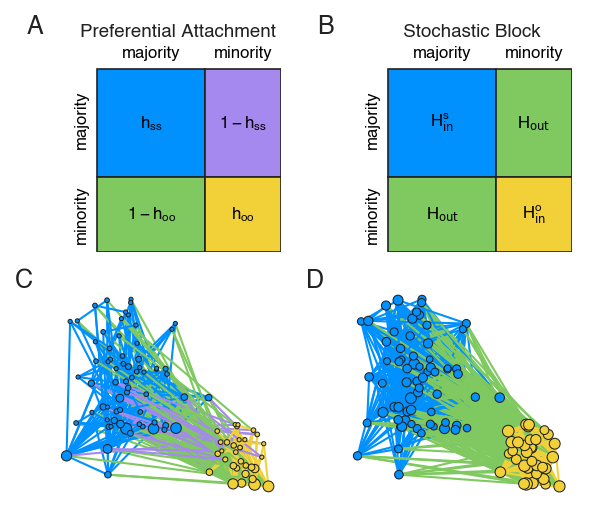

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import numpy as np

# ============================================================
# 2×2 FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(4, 3.5), dpi=dpival)

# -------------------------------------------------------------------
#  TOP LEFT — BA block diagram
# -------------------------------------------------------------------

rects_ba_block = [
    (0,           minority_h, majority_w, majority_h, r'$h_{ss}$',     maj_color),
    (majority_w,  minority_h, minority_w, majority_h, r'$1-h_{ss}$',  maj_min_color),

    (0,           0,          majority_w, minority_h, r'$1-h_{oo}$',  min_maj_color),
    (majority_w,  0,          minority_w, minority_h, r'$h_{oo}$',     min_color),
]

draw_block(axes[0,0], rects_ba_block, maj_color, maj_min_color, min_maj_color, min_color)
axes[0,0].set_title("    Preferential Attachment", fontsize=MEDIUM_SIZE, color=myblack, y=1., pad=-5)
customize_axes(axes[0,0], myblack)
axes[0,0].text(-0.05, 1.05, 'A', transform=axes[0,0].transAxes,
               fontsize=BIGGER_SIZE, fontweight='bold', va='top', ha='right', color=myblack)

# -------------------------------------------------------------------
#  TOP RIGHT — SBM block diagram
# -------------------------------------------------------------------

rects_sbm_block = [
    (0,           minority_h, majority_w, majority_h, r'$H_{\text{in}}^s$',   maj_color),
    (majority_w,  minority_h, minority_w, majority_h, r'$H_{\text{out}}$', min_maj_color),

    (0,           0,          majority_w, minority_h, r'$H_{\text{out}}$', min_maj_color),
    (majority_w,  0,          minority_w, minority_h, r'$H_{\text{in}}^o$',   min_color),
]

draw_block(axes[0,1], rects_sbm_block, maj_color, None, min_maj_color, min_color)
axes[0,1].set_title("     Stochastic Block", color=myblack, fontsize=MEDIUM_SIZE, y=1., pad=-5)
customize_axes(axes[0,1], myblack)
axes[0,1].text(-0.05, 1.05, 'B', transform=axes[0,1].transAxes,
               fontsize=BIGGER_SIZE, fontweight='bold', va='top', ha='right', color=myblack)

# -------------------------------------------------------------------
#  BOTTOM LEFT — BA network cartoon
# -------------------------------------------------------------------

ax = axes[1,0]
customize_axes(ax, myblack)
ax.text(-0.05, 1.05, 'C', transform=ax.transAxes,
        fontsize=BIGGER_SIZE, fontweight='bold', va='top', ha='right', color=myblack)

colors_nodes_ba = {
    n: min_color if group_attr_ba_small[n] == "minority" else maj_color
    for n in G_ba_small.nodes()
}
degrees_ba_small = dict(G_ba_small.degree)
edge_colors_ba = edge_colors_from_groups(G_ba_small, group_attr_ba_small, type="BA")

nx.draw_networkx_edges(G_ba_small, pos_ba_small,
                       edge_color=edge_colors_ba, width=edge_width, ax=ax)
nx.draw_networkx_nodes(
    G_ba_small,
    pos_ba_small,
    nodelist=list(G_ba_small.nodes()),
    node_size=[degrees_ba_small[n] * node_size_multiplier for n in G_ba_small.nodes()],
    node_color=list(colors_nodes_ba.values()),
    linewidths=0.5,
    edgecolors=myblack,
    ax=ax,
)
ax.axis("off")
ax.tick_params(labelsize=TICK_SIZE)


# -------------------------------------------------------------------
#  BOTTOM RIGHT — SBM network cartoon
# -------------------------------------------------------------------

ax = axes[1,1]
customize_axes(ax, myblack)
ax.text(-0.05, 1.05, 'D', transform=ax.transAxes,
        fontsize=BIGGER_SIZE, fontweight='bold', va='top', ha='right', color=myblack)

colors_nodes_sbm = {
    n: min_color if group_attr_sbm_small[n] == "minority" else maj_color
    for n in G_sbm_small.nodes()
}
degrees_sbm_small = dict(G_sbm_small.degree)
edge_colors_sbm = edge_colors_from_groups(G_sbm_small, group_attr_sbm_small, type="SBM")

nx.draw_networkx_edges(G_sbm_small, pos_sbm_small,
                       edge_color=edge_colors_sbm, width=edge_width, ax=ax)
nx.draw_networkx_nodes(
    G_sbm_small,
    pos_sbm_small,
    nodelist=list(G_sbm_small.nodes()),
    node_size=[degrees_sbm_small[n] * node_size_multiplier for n in G_sbm_small.nodes()],
    node_color=list(colors_nodes_sbm.values()),
    linewidths=0.5,
    edgecolors=myblack,
    ax=ax,
)
ax.axis("off")
ax.tick_params(labelsize=TICK_SIZE)

for ax in axes.flat:
    ax.title.set_fontfamily('Helvetica')
    ax.title.set_color(myblack)

plt.tight_layout()
from pyprojroot import here
plt.savefig(here("figures/figure_1_cartoon.pdf"))
plt.show()
